# TRIDENT â€” 2-Tier SAR Ship Classifier

**Tier 1: Binary Classifier (Cargo vs Not Cargo)**
**Tier 2: Multi-Class Classifier (Non-Cargo Ship Types)**

The class imbalance problem in all three datasets is that cargo ships dominate. A single multi-class model ends up biased toward predicting cargo. The fix is two separate ResNet-18 models in sequence:
- Tier 1 filters out cargo ships confidently using is_cargo column
- Tier 2 runs only on what Tier 1 says is not cargo, classifying the remaining ship types

Both tiers trained on 4 datasets: os1, os2, fusar, and a joint pool of all three combined.
Both tiers use ResNet-18 with layers 1 and 2 frozen.


## Configuration

In [1]:
import os
# import wandb
import torch
import pandas as pd
import numpy as np
import zipfile
import requests
from pathlib import Path

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

# ---------------------------------------------------------------------------
# Box download URLs â€” fill these in with your shared links
# Box direct download format: https://company.box.com/shared/static/<id>
# ---------------------------------------------------------------------------
BOX_URLS = {
    "os1": "https://virginia.box.com/shared/static/9tz0fm7kq6745qzgy22hia985uf6c3hz.zip",   # e.g. "https://company.box.com/shared/static/abc123"
    "os2": "https://virginia.box.com/shared/static/t5dt2l6dgc3oz8oeizj83e8938gx69yr.zip",
    "fs":  "https://virginia.box.com/shared/static/u1lmcljm3o75gseghv5acnd4417qrkn2.zip",
}

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path("..").resolve()
DATA_DIR     = PROJECT_ROOT / "data" / "classification"
DATA_DIR.mkdir(parents=True, exist_ok=True)


def download_and_extract(key: str, out_dir: Path) -> None:
    """Download a zip from Box and extract it to out_dir."""
    url = BOX_URLS[key]
    if not url:
        print(f"[{key}] No URL provided, skipping.")
        return
    if out_dir.exists() and any(out_dir.iterdir()):
        print(f"[{key}] Already extracted, skipping.")
        return
    zip_path = DATA_DIR / f"{key}.zip"
    print(f"[{key}] Downloading...")
    dl_url = url + ("?dl=1" if "?" not in url else "&dl=1")
    with requests.get(dl_url, stream=True) as r:
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"[{key}] Extracting...")
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(out_dir)
    zip_path.unlink()
    print(f"[{key}] Done -> {out_dir}")


# ---------------------------------------------------------------------------
# Download image folders
# ---------------------------------------------------------------------------
download_and_extract("os1", DATA_DIR / "os1")
download_and_extract("os2", DATA_DIR / "os2")
download_and_extract("fs",  DATA_DIR / "fs")

# ---------------------------------------------------------------------------
# Load CSVs (already in repo at data/classification/)
# ---------------------------------------------------------------------------
opensar1 = pd.read_csv(DATA_DIR / "opensar1_labels.csv")
opensar2 = pd.read_csv(DATA_DIR / "opensar2_labels.csv")
fusar    = pd.read_csv(DATA_DIR / "fusar_labels.csv")

# Resolve local image paths
opensar1["path"] = opensar1["path"].apply(lambda p: str(PROJECT_ROOT / p))
opensar2["path"] = opensar2["path"].apply(lambda p: str(PROJECT_ROOT / p))
fusar["path"]    = fusar["path"].apply(lambda p: str(PROJECT_ROOT / p))

print(f"OpenSARShip 1: {len(opensar1)} rows")
print(f"OpenSARShip 2: {len(opensar2)} rows")
print(f"FuSARShip:     {len(fusar)} rows")

fusar.head()

# Hyperparameters â€” same as baseline
BATCH_SIZE  = 32
EPOCHS      = 10
LR          = 1e-4
RANDOM_SEED = 42

[os1] Already extracted, skipping.
[os2] Already extracted, skipping.
[fs] Already extracted, skipping.
OpenSARShip 1: 11346 rows
OpenSARShip 2: 18864 rows
FuSARShip:     5101 rows


### Notes - Configuration

Same auto-detection setup as ClassificationPipeline. Same hyperparameters too so results stay comparable to the baseline. Models for this notebook get saved to models/2tier/ so they don't overwrite the baseline checkpoints.

Same WandB project as the baseline so everything shows up in one place and you can compare the two-tier results directly against the single model results.


## Imports and WandB Login

In [3]:
#import wandb
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

#wandb.login()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


### Notes - Imports

Exact same imports as ClassificationPipeline. Nothing new here, just needed the same stack of torch, torchvision, wandb, sklearn, and seaborn.


## Load Label CSVs

In [4]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path
import gdown

DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/19jLMSzHChVLk-vVAg2muNN2OALzksWob"

# Local directory to download into â€” sits next to this notebook
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "classification"

# Download from Google Drive if CSVs are not already present
if not (DATA_DIR / "opensar1_labels.csv").exists():
    print("Downloading classification folder from Google Drive...")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    gdown.download_folder(DRIVE_FOLDER_URL, output=str(DATA_DIR), quiet=False, use_cookies=False)
    print("Download complete.")
else:
    print(f"Data already present at {DATA_DIR}, skipping download.")

# Load all three label CSVs
opensar1 = pd.read_csv(DATA_DIR / "opensar1_labels.csv")
opensar2 = pd.read_csv(DATA_DIR / "opensar2_labels.csv")
fusar    = pd.read_csv(DATA_DIR / "fusar_labels.csv")

# Resolve image paths to absolute local paths
opensar1["path"] = opensar1["path"].apply(lambda p: str(PROJECT_ROOT / p))
opensar2["path"] = opensar2["path"].apply(lambda p: str(PROJECT_ROOT / p))
fusar["path"]    = fusar["path"].apply(lambda p: str(PROJECT_ROOT / p))

# print stats
print(f"OpenSARShip 1: {len(opensar1)} rows")
print(f"OpenSARShip 2: {len(opensar2)} rows")
print(f"FuSARShip:     {len(fusar)} rows")

fusar.head()


Data already present at /sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final_project/data/classification, skipping download.
OpenSARShip 1: 11346 rows
OpenSARShip 2: 18864 rows
FuSARShip:     5101 rows


,fs_id,path,class_label,ship_type,polarization,label,is_cargo,google_path
0,fs_0001,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/AggregatesCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
1,fs_0002,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/AggregatesCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
2,fs_0003,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
3,fs_0004,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...
4,fs_0005,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo/BulkCarrier,NaN,NaN,cargo,1,/content/drive/MyDrive/classification/fs/fs_00...


In [8]:
# Build mapping from all unique labels across all three datasets
unique_labels = sorted(set(opensar1['label']).union(
                       set(opensar2['label'])).union(
                       set(fusar['label'])))

label_to_int = {label: i for i, label in enumerate(unique_labels)}

# Apply mapping independently
opensar1.loc[:, 'label_id'] = opensar1['label'].map(label_to_int)
opensar2.loc[:, 'label_id'] = opensar2['label'].map(label_to_int)
fusar.loc[:, 'label_id']    = fusar['label'].map(label_to_int)

print("Label mapping:", label_to_int)

# drop unknown values of the datasets
opensar1 = opensar1[opensar1['label'] != 'unknown']
opensar2 = opensar2[opensar2['label'] != 'unknown']
fusar    = fusar[fusar['label'] != 'unknown']

# length after creation
print(f"OpenSARShip 1: {len(opensar1)} rows")
print(f"OpenSARShip 2: {len(opensar2)} rows")
print(f"FuSARShip:     {len(fusar)} rows")

Label mapping: {'cargo': 0, 'engineering': 1, 'other': 2, 'passenger': 3, 'tanker': 4}
OpenSARShip 1: 10602 rows
OpenSARShip 2: 16280 rows
FuSARShip:     5101 rows


### Notes - Load Label CSVs

Same loading logic as before. The key thing here is that the is_cargo column already exists in all three CSVs with 0 or 1. That's what drives the whole two-tier approach. Tier 1 trains directly on that column so we don't need to derive anything.

The printout shows how imbalanced things are per dataset between cargo and non-cargo. That number is exactly why a single multi-class model struggles the cargo samples are swamping everything else during training.


## Build Joint Dataset

In [9]:
# Joint dataset pools all three together into one combined training set
joint = pd.concat([opensar1, opensar2, fusar], ignore_index=True)

print(f'Joint dataset: {len(joint)} rows')
print(f'  cargo: {joint["is_cargo"].sum()} | not cargo: {(joint["is_cargo"]==0).sum()}')
print(f'\nFull label distribution in joint:')
print(joint['label'].value_counts().to_string())


Joint dataset: 31983 rows
  cargo: 21247 | not cargo: 10736

Full label distribution in joint:
label
cargo          21247
tanker          5823
other           3796
engineering      876
passenger        241


### Notes - Joint Dataset

The joint dataset is just all three concatenated into one. The joint model outperformed individual models on the test set so we are training on all 4 variations: os1, os2, fusar, and joint. This gives us 4 Tier 1 models and 4 Tier 2 models, 8 total, so we can see which combination actually performs best.

The imbalance in the joint set is even more visible here since you are stacking three already imbalanced datasets. That is exactly the problem Tier 1 is designed to fix.


## Tier 1 - Label Setup (Binary: Cargo vs Not Cargo)

In [10]:
# Tier 1 is binary: is_cargo column directly gives us 0 or 1
# 0 = not cargo, 1 = cargo
TIER1_CLASS_NAMES = ['not_cargo', 'cargo']
TIER1_NUM_CLASSES = 2

# Each domain dataframe already has is_cargo as 0/1 â€” use it directly as label_id
for df in [opensar1, opensar2, fusar, joint]:
    df['t1_label_id'] = df['is_cargo'].astype(int)

print('Tier 1 label mapping: 0 = not_cargo, 1 = cargo')
print(f'Number of classes: {TIER1_NUM_CLASSES}')

for name, df in [('os1', opensar1), ('os2', opensar2), ('fusar', fusar), ('joint', joint)]:
    counts = df['t1_label_id'].value_counts().sort_index()
    print(f'  {name}: not_cargo={counts.get(0,0)} | cargo={counts.get(1,0)}')


Tier 1 label mapping: 0 = not_cargo, 1 = cargo
Number of classes: 2
  os1: not_cargo=2362 | cargo=8240
  os2: not_cargo=5387 | cargo=10893
  fusar: not_cargo=2987 | cargo=2114
  joint: not_cargo=10736 | cargo=21247


### Notes - Tier 1 Label Setup

Tier 1 is a binary classification problem. We don't need to build a fancy label mapping here because is_cargo is already 0 or 1 in the CSV. Not cargo is 0, cargo is 1. That is the entire job of Tier 1, just learn to separate those two groups. - Garebear make sure this is accurate


## Tier 2 - Label Setup (Multi-Class: Non-Cargo Ship Types)

In [16]:
# Tier 2 only sees non-cargo ships
# Filter each dataset to is_cargo == 0
os1_nc    = opensar1[opensar1['is_cargo'] == 0].reset_index(drop=True)
os2_nc    = opensar2[opensar2['is_cargo'] == 0].reset_index(drop=True)
fusar_nc  = fusar[fusar['is_cargo'] == 0].reset_index(drop=True)
joint_nc  = joint[joint['is_cargo'] == 0].reset_index(drop=True)

# Build label mapping from non-cargo labels only
nc_labels = (set(os1_nc['label'])
             .union(set(os2_nc['label']))
             .union(set(fusar_nc['label'])))

TIER2_LABEL_TO_INT = {label: i for i, label in enumerate(sorted(nc_labels))}
TIER2_INT_TO_LABEL = {v: k for k, v in TIER2_LABEL_TO_INT.items()}
TIER2_CLASS_NAMES  = [TIER2_INT_TO_LABEL[i] for i in range(len(TIER2_LABEL_TO_INT))]
TIER2_NUM_CLASSES  = len(TIER2_CLASS_NAMES)

print(f'Tier 2 label mapping: {TIER2_LABEL_TO_INT}')
print(f'Class names: {TIER2_CLASS_NAMES}')
print(f'Number of classes: {TIER2_NUM_CLASSES}')

for df in [os1_nc, os2_nc, fusar_nc, joint_nc]:
    df['t2_label_id'] = df['label'].map(TIER2_LABEL_TO_INT)

print(f'\nNon-cargo sample counts:')
for name, df in [('os1_nc', os1_nc), ('os2_nc', os2_nc), ('fusar_nc', fusar_nc), ('joint_nc', joint_nc)]:
    print(f'  {name}: {len(df)} rows')
    print(f'  {df["label"].value_counts().to_string()}')
    print()


Tier 2 label mapping: {'engineering': 0, 'other': 1, 'passenger': 2, 'tanker': 3}
Class names: ['engineering', 'other', 'passenger', 'tanker']
Number of classes: 4

Non-cargo sample counts:
  os1_nc: 2362 rows
  label
tanker         1670
other           384
engineering     270
passenger        38

  os2_nc: 5387 rows
  label
tanker         3905
other           876
engineering     467
passenger       139

  fusar_nc: 2987 rows
  label
other          2536
tanker          248
engineering     139
passenger        64

  joint_nc: 10736 rows
  label
tanker         5823
other          3796
engineering     876
passenger       241



### Notes - Tier 2 Label Setup

Tier 2 only trains on the non-cargo rows. We filter first and then build the label mapping from whatever is left. Cargo is completely gone from this stage, Tier 1 already handled it. The remaining classes are things like tanker, passenger, engineering, other depending on what is in the dataset after filtering.

The non-cargo subsets are going to be much smaller than the full datasets which is expected. The point is that now the class distribution within Tier 2 should be a lot more balanced than the original data was with cargo included. That should help the model actually learn to distinguish between these rarer ship types instead of ignoring them.


## Dataset Class and Transforms

In [20]:
RESNET_MEAN = [0.485, 0.456, 0.406]
RESNET_STD  = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15, fill=0),
    transforms.ToTensor(),
    transforms.Normalize(mean=RESNET_MEAN, std=RESNET_STD)
])

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=RESNET_MEAN, std=RESNET_STD)
])


class SARDataset(Dataset):
    def __init__(self, dataframe, label_col, transform=None):
        """
        label_col: which column to use as the label ('t1_label_id' for Tier 1, 't2_label_id' for Tier 2)
        """
        self.df        = dataframe.reset_index(drop=True)
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(row['path']).convert('L')
        except (FileNotFoundError, OSError) as e:
            raise RuntimeError(f'Could not load image at index {idx}: {row["path"]}') from e
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(row[self.label_col], dtype=torch.long)


print('SARDataset and transforms defined.')
print('Note: pass label_col="t1_label_id" for Tier 1, "t2_label_id" for Tier 2')


SARDataset and transforms defined.
Note: pass label_col="t1_label_id" for Tier 1, "t2_label_id" for Tier 2


### Notes - Dataset Class and Transforms

Same SARDataset class as ClassificationPipeline with one change: it now takes a label_col argument. This is because the same image rows need to work for both tiers but pull from different label columns. For Tier 1 you pass t1_label_id which is the binary cargo/not-cargo column. For Tier 2 you pass t2_label_id which is the multi-class non-cargo label.

Everything else is identical to before, same transforms, same augmentation strategy, same ImageNet normalization.


## Tier 1 - Splits and DataLoaders

In [ ]:
def make_test_split(df, label_col, random_seed=RANDOM_SEED):
    """Split off 20% test indices once, shared across tiers."""
    labels = df[label_col].values
    idx    = np.arange(len(df))

    if df['source'].values[0] == "joint":
        stratify_col = (df['source'] + '_' + df[label_col].astype(str)).values
    else:
        stratify_col = labels

    trainval_idx, test_idx = train_test_split(
        idx, test_size=0.20, stratify=stratify_col, random_state=random_seed
    )
    return trainval_idx, test_idx

def make_splits(df, label_col, trainval_idx, test_idx, random_seed=RANDOM_SEED):
    """
    Stratified 70/10/20 train/val/test split.
    Accepts pre-split test indices so tier1 and tier2 share the same test set.
    """
    labels = df[label_col].values

    if df['source'].values[0] == "joint":
        stratify_col = (df['source'] + '_' + df[label_col].astype(str)).values
    else:
        stratify_col = labels

    train_idx, val_idx = train_test_split(
        trainval_idx, test_size=0.10,
        stratify=stratify_col[trainval_idx], random_state=random_seed
    )

    full_train = SARDataset(df, label_col, transform=transform_train)
    full_eval  = SARDataset(df, label_col, transform=transform_eval)

    result = {
        'train_dataset': Subset(full_train, train_idx),
        'val_dataset':   Subset(full_eval,  val_idx),
        'test_dataset':  Subset(full_eval,  test_idx),
    }
    result['train_loader'] = DataLoader(result['train_dataset'], batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    result['val_loader']   = DataLoader(result['val_dataset'],   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    result['test_loader']  = DataLoader(result['test_dataset'],  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    return result, len(train_idx), len(val_idx), len(test_idx)


# Add source columns
opensar1['source'] = 'os1'
opensar2['source'] = 'os2'
fusar['source']    = 'fusar'
joint['source']    = 'joint'

# Split indices once per dataset, shared across tiers
shared_splits = {}
for name, df in [('os1', opensar1), ('os2', opensar2), ('fusar', fusar), ('joint', joint)]:
    shared_splits[name] = make_test_split(df, 't1_label_id')  # same rows regardless of tier

# Build Tier 1 domains across all 4 datasets
tier1_domains = {}
for name, df in [('os1', opensar1), ('os2', opensar2), ('fusar', fusar), ('joint', joint)]:
    trainval_idx, test_idx = shared_splits[name]

    tier1_domains[name], n_train, n_val, n_test = make_splits(df, 't1_label_id', trainval_idx, test_idx)
    print(f'Tier 1 | {name}: train={n_train} | val={n_val} | test={n_test}')

Tier 1 | os1: train=7420 | val=1061 | test=2121
Tier 1 | os2: train=11396 | val=1628 | test=3256
Tier 1 | fusar: train=3570 | val=510 | test=1021
Tier 1 | joint: train=22387 | val=3199 | test=6397


### Notes - Tier 1 Splits and DataLoaders

Same stratified 70/10/20 split as before, now wrapped into a reusable make_splits function since we need to run it for both tiers across 4 datasets each. Stratified on t1_label_id here so both cargo and not-cargo maintain their proportions in each split.

We run this for all 4 datasets: os1, os2, fusar, and joint. That gives us 4 independent Tier 1 binary classifiers to train and compare.


## Tier 2 - Splits and DataLoaders

In [22]:
opensar1

,os1_id,path,class_label,ship_type,polarization,label,is_cargo,google_path,label_id,t1_label_id,source
0,os1_00001,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo,70,vh,cargo,1,/content/drive/MyDrive/classification/os1/os1_...,0,1,os1
1,os1_00002,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo,70,vv,cargo,1,/content/drive/MyDrive/classification/os1/os1_...,0,1,os1
2,os1_00003,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo,70,vh,cargo,1,/content/drive/MyDrive/classification/os1/os1_...,0,1,os1
3,os1_00004,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo,70,vv,cargo,1,/content/drive/MyDrive/classification/os1/os1_...,0,1,os1
4,os1_00005,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Cargo,70,vh,cargo,1,/content/drive/MyDrive/classification/os1/os1_...,0,1,os1
...,...,...,...,...,...,...,...,...,...,...,...
11341,os1_11342,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Tanker,80,vv,tanker,0,/content/drive/MyDrive/classification/os1/os1_...,4,0,os1
11342,os1_11343,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Tanker,80,vh,tanker,0,/content/drive/MyDrive/classification/os1/os1_...,4,0,os1
11343,os1_11344,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Tanker,80,vv,tanker,0,/content/drive/MyDrive/classification/os1/os1_...,4,0,os1
11344,os1_11345,/sfs/gpfs/tardis/home/nbz3de/fold/ds6050_final...,Towing,31,vh,engineering,0,/content/drive/MyDrive/classification/os1/os1_...,1,0,os1


In [23]:
# 3. Build tier 2 splits, excluding any rows seen in tier 1 test set
shared_splits_nc = {}
for name, (full_df, nc_df) in [
    ('os1',   (opensar1, os1_nc)),
    ('os2',   (opensar2, os2_nc)),
    ('fusar', (fusar,    fusar_nc)),
    ('joint', (joint,    joint_nc)),
]:
    _, test_idx = shared_splits[name]
    tier1_test_set = set(test_idx)

    safe_idx = np.array([i for i, orig in enumerate(nc_df.index) if orig not in tier1_test_set])

    labels       = nc_df['t2_label_id'].values
    stratify_col = labels[safe_idx]

    safe_trainval, safe_test = train_test_split(
        safe_idx, test_size=0.20, stratify=stratify_col, random_state=RANDOM_SEED
    )
    shared_splits_nc[name] = (safe_trainval, safe_test)
    print(f'{name}: {len(safe_idx)} safe rows ({len(nc_df) - len(safe_idx)} excluded from tier1 test)')

# 4. Build tier 2
tier2_domains = {}
for name, df in [('os1', os1_nc), ('os2', os2_nc), ('fusar', fusar_nc), ('joint', joint_nc)]:
    trainval_idx, test_idx = shared_splits_nc[name]
    tier2_domains[name], n_train, n_val, n_test = make_splits(df, 't2_label_id', trainval_idx, test_idx)
    print(f'Tier 2 | {name}: train={n_train} | val={n_val} | test={n_test}')


os1: 1901 safe rows (461 excluded from tier1 test)
os2: 4332 safe rows (1055 excluded from tier1 test)
fusar: 2400 safe rows (587 excluded from tier1 test)
joint: 8600 safe rows (2136 excluded from tier1 test)
Tier 2 | os1: train=1330 | val=190 | test=381
Tier 2 | os2: train=3031 | val=434 | test=867
Tier 2 | fusar: train=1680 | val=240 | test=480
Tier 2 | joint: train=6020 | val=860 | test=1720


### Notes - Tier 2 Splits and DataLoaders

Same make_splits function, now applied to the non-cargo filtered dataframes. These are smaller datasets since cargo is gone, which you will see in the sample counts. The label column is t2_label_id now which maps to the non-cargo ship types.

Because the non-cargo classes are more balanced with each other now, the stratified split here is more meaningful than it was for the full datasets where cargo dominated everything.


## Model - ResNet-18 (Used for Both Tiers)

In [24]:
def build_resnet18(num_classes):
    """
    ResNet-18 with ImageNet weights.
    Frozen: layer1, layer2
    Trainable: layer3, layer4, fc
    Works for any number of output classes â€” used for both Tier 1 (2 classes) and Tier 2 (N classes).
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    for param in model.parameters():
        param.requires_grad = False

    for name, param in model.named_parameters():
        if any(name.startswith(p) for p in ['layer3', 'layer4', 'fc']):
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')
    return model


# Sanity check on Tier 1 (binary)
print('Sanity check Tier 1 (binary, 2 classes):')
test_model = build_resnet18(TIER1_NUM_CLASSES).to(device)
test_opt   = Adam(filter(lambda p: p.requires_grad, test_model.parameters()), lr=LR)
test_crit  = nn.CrossEntropyLoss()
test_model.train()
for i, (imgs, lbls) in enumerate(tier1_domains['os1']['train_loader']):
    if i >= 3: break
    imgs, lbls = imgs.to(device), lbls.to(device)
    test_opt.zero_grad()
    loss = test_crit(test_model(imgs), lbls)
    loss.backward()
    test_opt.step()
    print(f'  Batch {i+1} loss: {loss.item():.4f}')
del test_model, test_opt

# Sanity check on Tier 2 (multi-class)
print(f'\nSanity check Tier 2 (multi-class, {TIER2_NUM_CLASSES} classes):')
test_model = build_resnet18(TIER2_NUM_CLASSES).to(device)
test_opt   = Adam(filter(lambda p: p.requires_grad, test_model.parameters()), lr=LR)
test_model.train()
for i, (imgs, lbls) in enumerate(tier2_domains['os1']['train_loader']):
    if i >= 3: break
    imgs, lbls = imgs.to(device), lbls.to(device)
    test_opt.zero_grad()
    loss = test_crit(test_model(imgs), lbls)
    loss.backward()
    test_opt.step()
    print(f'  Batch {i+1} loss: {loss.item():.4f}')
del test_model, test_opt


Sanity check Tier 1 (binary, 2 classes):
Trainable params: 10,494,466 / 11,177,538 (93.9%)
  Batch 1 loss: 0.6725
  Batch 2 loss: 0.6189
  Batch 3 loss: 0.6397

Sanity check Tier 2 (multi-class, 4 classes):
Trainable params: 10,495,492 / 11,178,564 (93.9%)
  Batch 1 loss: 1.3605
  Batch 2 loss: 1.1478
  Batch 3 loss: 1.1954


### Notes - Model

Same ResNet-18 setup as the baseline â€” layers 1 and 2 frozen, layers 3 and 4 and FC trainable. The only difference is the build_resnet18 function now takes num_classes as an argument so we can reuse the exact same function for Tier 1 (2 classes, binary) and Tier 2 (however many non cargo classes exist in the data). The architecture is identical, just the output size changes.

We run a quick sanity check on both tiers before committing to a full training run. If the loss is not going down after a few batches something is wrong and you want to catch it early rather than waste GPU time.


## Training Loop

In [25]:
def train_model(model, run_name, class_names, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, save_dir='tier_weights'):
    """
    Trains model, saves best checkpoint by val accuracy.
    run_name should describe both the tier and dataset, e.g. 'tier1_os1' or 'tier2_joint'
    """
    # wandb.init(
    #     project=WANDB_PROJECT,
    #     entity=WANDB_ENTITY,
    #     name=run_name,
    #     config={
    #         'model': 'ResNet-18',
    #         'run': run_name,
    #         'epochs': epochs,
    #         'learning_rate': lr,
    #         'batch_size': BATCH_SIZE,
    #         'optimizer': 'Adam',
    #         'num_classes': len(class_names),
    #         'class_names': class_names,
    #     },
    #     reinit=True
    # )

    os.makedirs(save_dir, exist_ok=True)

    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc  = 100.0 * correct / total

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels_list = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total   += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                all_preds.extend(predicted.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader)
        val_acc  = 100.0 * correct / total

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'tier_weights/{run_name}_best.pth')
        
        # wandb.log({'epoch': epoch+1, 'train_loss': train_loss, 'val_loss': val_loss,
        #            'train_acc': train_acc, 'val_acc': val_acc})
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f'[{run_name}] Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

    # wandb.log({'val_confusion_matrix': wandb.plot.confusion_matrix(
    #     probs=None, y_true=all_labels_list, preds=all_preds, class_names=class_names)})

    best_path = os.path.join(save_dir, f'{run_name}_best.pth')
    model.load_state_dict(torch.load(best_path, map_location=device))
    print(f'[{run_name}] Loaded best checkpoint (val acc: {best_val_acc:.2f}%)')
    # wandb.finish()
    return model, history

### Notes - Training Loop

Same training loop as the baseline, just updated so run_name describes both the tier and the dataset, for example tier1_os1 or tier2_joint. This way when you look at WandB you can see all 8 runs labeled clearly and compare them.

Everything else is the same, Adam optimizer, CrossEntropyLoss, saves the best checkpoint by val accuracy and reloads it at the end so what gets returned is the best model not just the last epoch.


## Train All Tier 1 Models (Binary Classifier)

In [26]:
for name, d in tier1_domains.items():
    print(f"\n{'='*55}")
    print(f'  Tier 1 Training: {name}')
    print(f"{'='*55}")
    d['model'] = build_resnet18(TIER1_NUM_CLASSES)
    d['trained_model'], d['history'] = train_model(
        d['model'], f'tier1_{name}', TIER1_CLASS_NAMES,
        d['train_loader'], d['val_loader']
    )



  Tier 1 Training: os1
Trainable params: 10,494,466 / 11,177,538 (93.9%)
[tier1_os1] Epoch 1/10 | Train Loss: 0.4569 | Val Loss: 0.4254 | Val Acc: 80.11%
[tier1_os1] Epoch 2/10 | Train Loss: 0.4277 | Val Loss: 0.4182 | Val Acc: 79.83%
[tier1_os1] Epoch 3/10 | Train Loss: 0.4182 | Val Loss: 0.4077 | Val Acc: 82.09%
[tier1_os1] Epoch 4/10 | Train Loss: 0.4070 | Val Loss: 0.4123 | Val Acc: 80.68%
[tier1_os1] Epoch 5/10 | Train Loss: 0.4059 | Val Loss: 0.4204 | Val Acc: 81.24%
[tier1_os1] Epoch 6/10 | Train Loss: 0.3959 | Val Loss: 0.4179 | Val Acc: 81.53%
[tier1_os1] Epoch 7/10 | Train Loss: 0.3937 | Val Loss: 0.3959 | Val Acc: 83.22%
[tier1_os1] Epoch 8/10 | Train Loss: 0.3855 | Val Loss: 0.4192 | Val Acc: 79.74%
[tier1_os1] Epoch 9/10 | Train Loss: 0.3813 | Val Loss: 0.3986 | Val Acc: 81.53%
[tier1_os1] Epoch 10/10 | Train Loss: 0.3747 | Val Loss: 0.4284 | Val Acc: 80.77%
[tier1_os1] Loaded best checkpoint (val acc: 83.22%)

  Tier 1 Training: os2
Trainable params: 10,494,466 / 11,177,


### Notes - Train All Tier 1 Models

This trains 4 independent binary classifiers, one per dataset. Each one is only trying to answer: is this a cargo ship or not. Because it is a binary problem the model has a much easier job than the original 5-class model and should converge faster and hit higher accuracy.

The joint model here is the most important one for the final pipeline since it has seen the most variety of SAR imagery across sensors. The per-dataset models are useful for comparison and understanding how sensor-specific the cargo/not-cargo distinction is.


## Train All Tier 2 Models (Multi-Class Non-Cargo Classifier)

In [27]:
for name, d in tier2_domains.items():
    print(f"\n{'='*55}")
    print(f'  Tier 2 Training: {name}')
    print(f"{'='*55}")
    d['model'] = build_resnet18(TIER2_NUM_CLASSES)
    d['trained_model'], d['history'] = train_model(
        d['model'], f'tier2_{name}', TIER2_CLASS_NAMES,
        d['train_loader'], d['val_loader']
    )



  Tier 2 Training: os1
Trainable params: 10,495,492 / 11,178,564 (93.9%)
[tier2_os1] Epoch 1/10 | Train Loss: 0.9961 | Val Loss: 0.7785 | Val Acc: 73.16%
[tier2_os1] Epoch 2/10 | Train Loss: 0.7462 | Val Loss: 0.6746 | Val Acc: 77.89%
[tier2_os1] Epoch 3/10 | Train Loss: 0.7107 | Val Loss: 0.6783 | Val Acc: 77.37%
[tier2_os1] Epoch 4/10 | Train Loss: 0.6756 | Val Loss: 0.6208 | Val Acc: 78.42%
[tier2_os1] Epoch 5/10 | Train Loss: 0.6404 | Val Loss: 0.6891 | Val Acc: 74.74%
[tier2_os1] Epoch 6/10 | Train Loss: 0.6355 | Val Loss: 0.6158 | Val Acc: 79.47%
[tier2_os1] Epoch 7/10 | Train Loss: 0.5970 | Val Loss: 0.6493 | Val Acc: 78.95%
[tier2_os1] Epoch 8/10 | Train Loss: 0.5920 | Val Loss: 0.5902 | Val Acc: 80.53%
[tier2_os1] Epoch 9/10 | Train Loss: 0.5605 | Val Loss: 0.6746 | Val Acc: 78.42%
[tier2_os1] Epoch 10/10 | Train Loss: 0.5152 | Val Loss: 0.6697 | Val Acc: 77.89%
[tier2_os1] Loaded best checkpoint (val acc: 80.53%)

  Tier 2 Training: os2
Trainable params: 10,495,492 / 11,178,

### Notes - Train All Tier 2 Models

Same loop now for the Tier 2 multi-class classifiers. These train only on non-cargo ships so the model is not fighting against a cargo-dominated dataset anymore. The class distribution going into Tier 2 should be much more balanced which is the whole point of the two-tier design.

These models will likely struggle more than Tier 1 because distinguishing between tankers, passengers, and engineering ships is a harder problem than just separating cargo from everything else. But removing cargo from the equation should still be a meaningful improvement over the baseline single model.


## Training Curves

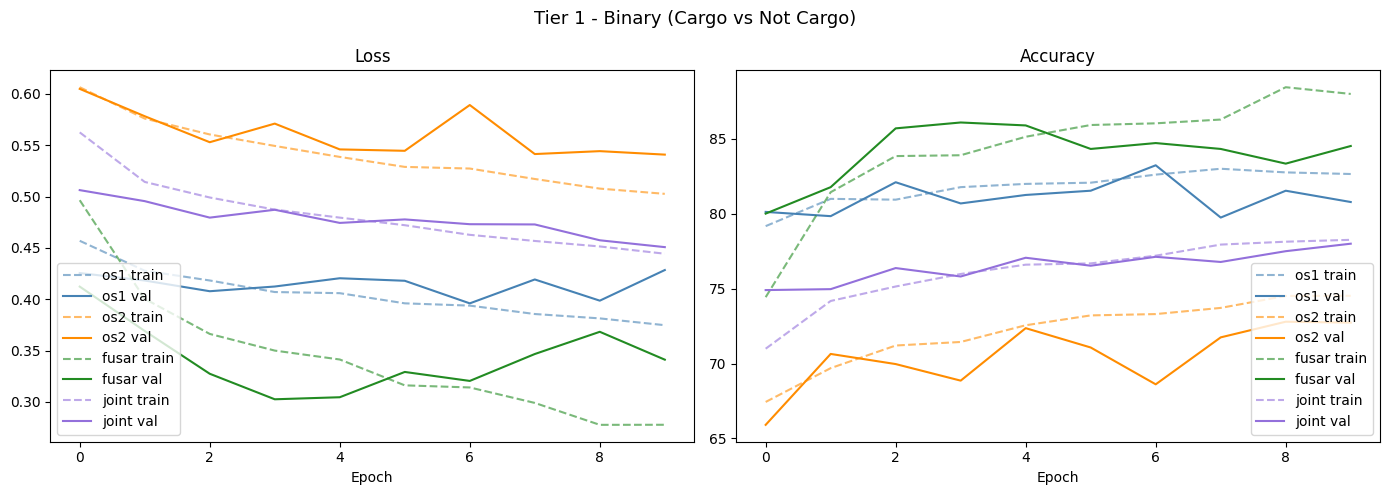

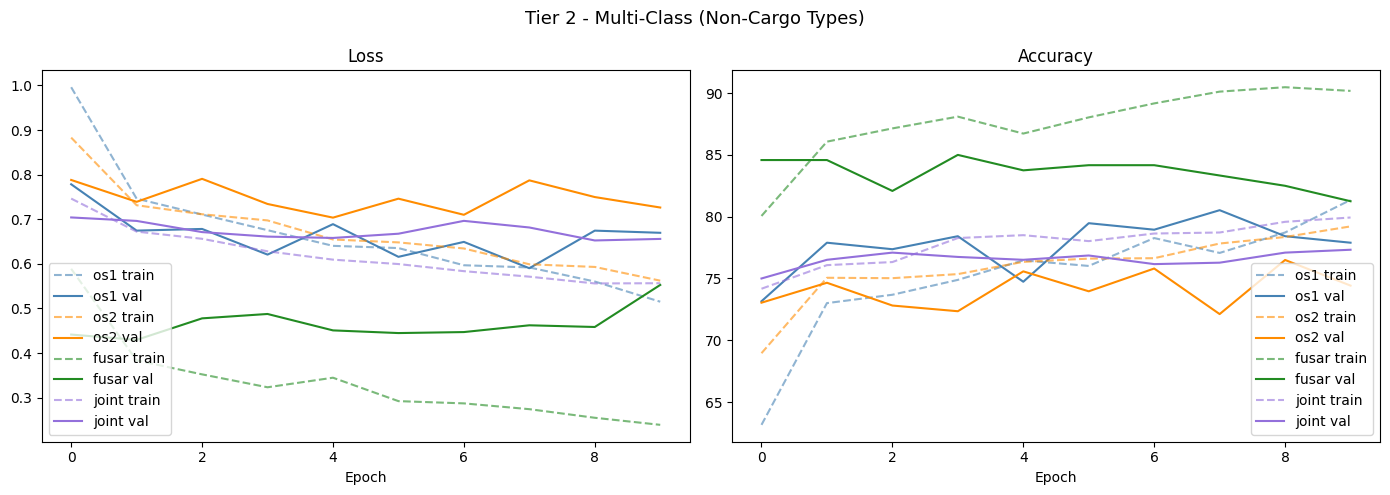

In [28]:
colors = {'os1': 'steelblue', 'os2': 'darkorange', 'fusar': 'forestgreen', 'joint': 'mediumpurple'}

for tier_name, domains in [('Tier 1 - Binary (Cargo vs Not Cargo)', tier1_domains),
                             ('Tier 2 - Multi-Class (Non-Cargo Types)', tier2_domains)]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(tier_name, fontsize=13)

    for key, d in domains.items():
        h = d['history']
        c = colors[key]
        ax1.plot(h['train_loss'], linestyle='dashed', color=c, alpha=0.6, label=f'{key} train')
        ax1.plot(h['val_loss'],   linestyle='solid',  color=c, label=f'{key} val')
        ax2.plot(h['train_acc'],  linestyle='dashed', color=c, alpha=0.6, label=f'{key} train')
        ax2.plot(h['val_acc'],    linestyle='solid',  color=c, label=f'{key} val')

    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
    plt.tight_layout()
    fname = tier_name.split(' - ')[0].lower().replace(' ', '_') + '_curves.png'
    plt.savefig(os.path.join('misc', fname), dpi=150)
    plt.show()

import json
# save off history
history_tier = {
    tier_name: {key: d['history'] for key, d in domains.items()}
    for tier_name, domains in [('Tier 1 - Binary (Cargo vs Not Cargo)', tier1_domains),
                                ('Tier 2 - Multi-Class (Non-Cargo Types)', tier2_domains)]
}

os.makedirs('misc', exist_ok=True)
with open('misc/history_tier.json', 'w') as f:
    json.dump(history_tier, f, indent=2)


### Notes - Training Curves

Two separate plots now, one for each tier. Tier 1 should look much cleaner since binary classification is an easier problem and you should see higher accuracy and lower loss compared to the baseline single model curves.

Tier 2 curves are the more interesting ones to look at. If the two-tier approach is working you should see better performance on the non-cargo classes compared to what the baseline model was able to achieve on those same classes. If the curves look similar to before it might mean the architecture needs more work or the non-cargo data is just genuinely hard to distinguish.


## Test Set Evaluation

Running Tier 1 test evaluation...

[tier1_os1] Test Accuracy: 81.61% (1731/2121)
              precision    recall  f1-score   support

   not_cargo       0.60      0.52      0.56       473
       cargo       0.87      0.90      0.88      1648

    accuracy                           0.82      2121
   macro avg       0.73      0.71      0.72      2121
weighted avg       0.81      0.82      0.81      2121



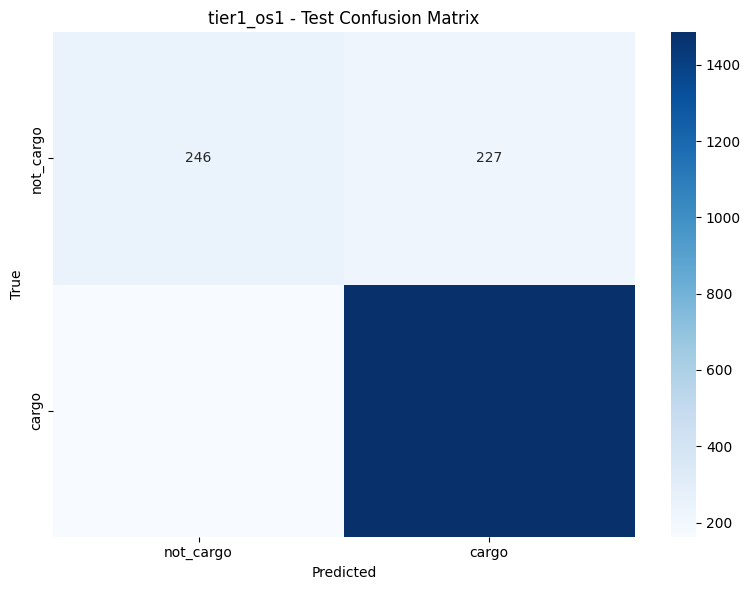


[tier1_os2] Test Accuracy: 71.90% (2341/3256)
              precision    recall  f1-score   support

   not_cargo       0.58      0.53      0.56      1077
       cargo       0.78      0.81      0.79      2179

    accuracy                           0.72      3256
   macro avg       0.68      0.67      0.68      3256
weighted avg       0.71      0.72      0.72      3256



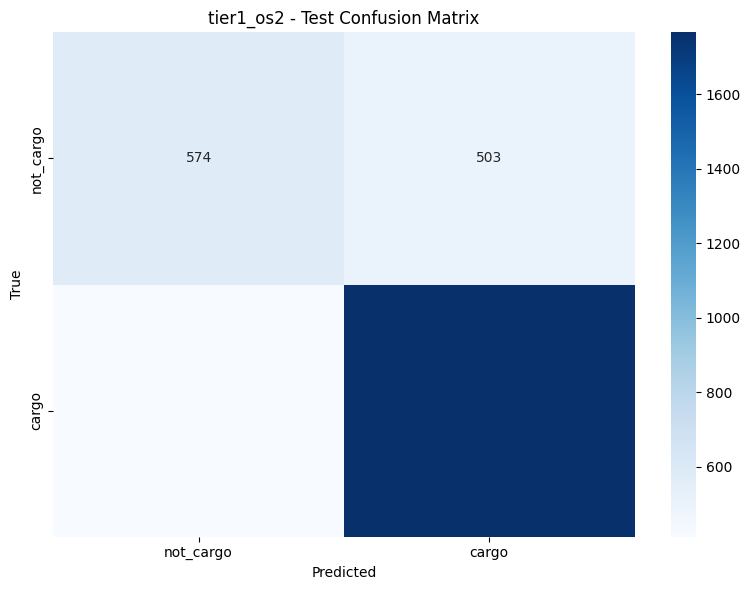


[tier1_fusar] Test Accuracy: 84.13% (859/1021)
              precision    recall  f1-score   support

   not_cargo       0.88      0.84      0.86       598
       cargo       0.79      0.84      0.82       423

    accuracy                           0.84      1021
   macro avg       0.84      0.84      0.84      1021
weighted avg       0.84      0.84      0.84      1021



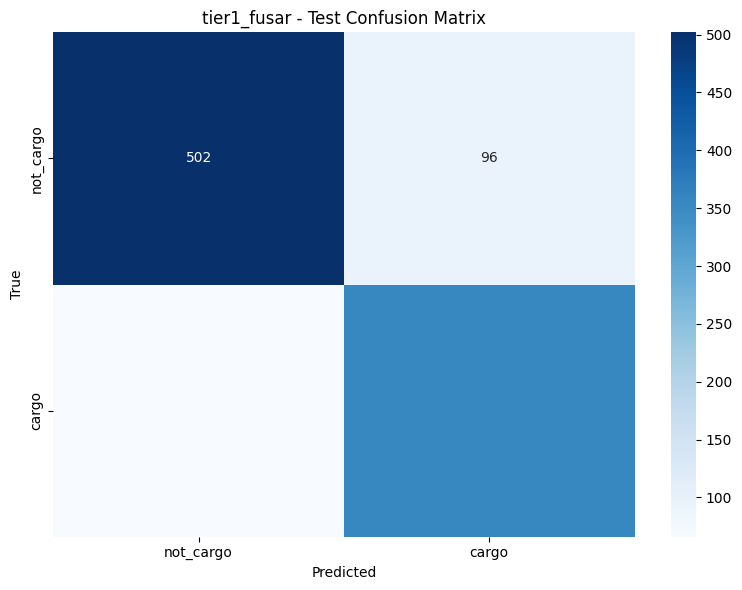


[tier1_joint] Test Accuracy: 77.43% (4953/6397)
              precision    recall  f1-score   support

   not_cargo       0.71      0.54      0.62      2147
       cargo       0.79      0.89      0.84      4250

    accuracy                           0.77      6397
   macro avg       0.75      0.72      0.73      6397
weighted avg       0.77      0.77      0.77      6397



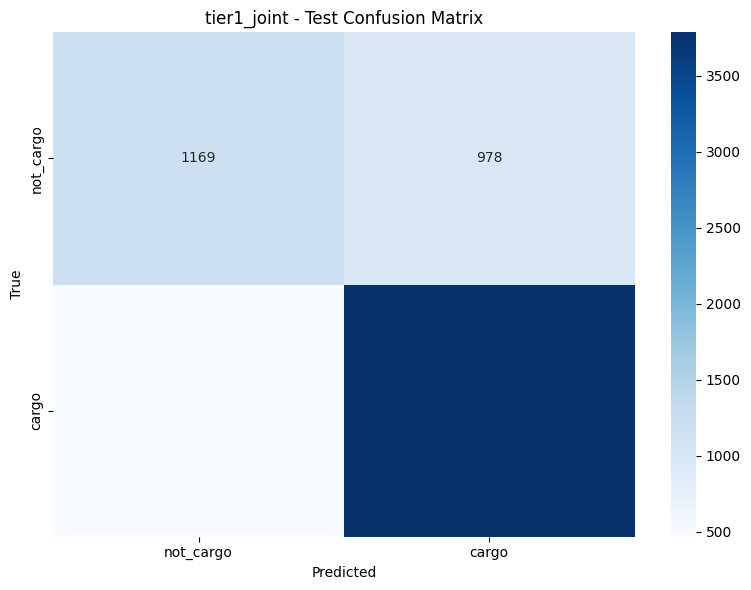


Running Tier 2 test evaluation...

[tier2_os1] Test Accuracy: 78.74% (300/381)
              precision    recall  f1-score   support

 engineering       0.50      0.41      0.45        44
       other       0.76      0.31      0.44        61
   passenger       0.00      0.00      0.00         6
      tanker       0.82      0.97      0.89       270

    accuracy                           0.79       381
   macro avg       0.52      0.42      0.45       381
weighted avg       0.76      0.79      0.75       381



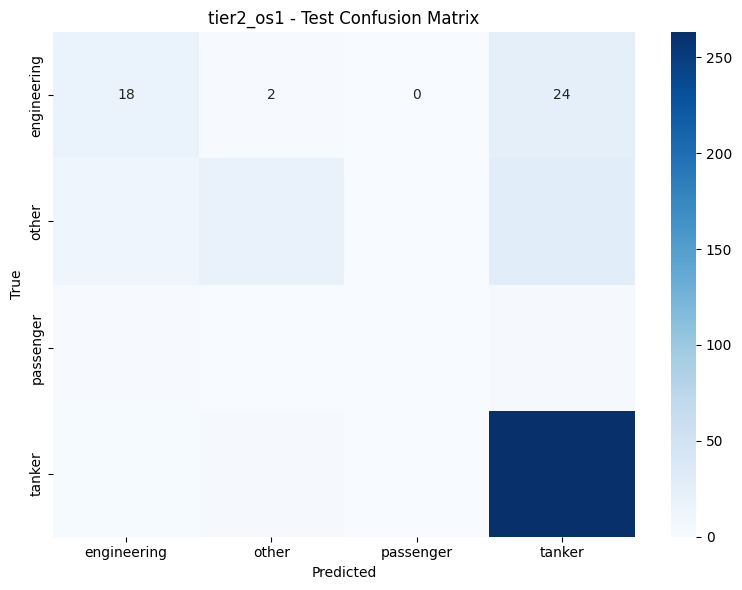


[tier2_os2] Test Accuracy: 75.43% (654/867)
              precision    recall  f1-score   support

 engineering       0.33      0.04      0.07        74
       other       0.55      0.29      0.38       141
   passenger       0.67      0.10      0.17        21
      tanker       0.78      0.96      0.86       631

    accuracy                           0.75       867
   macro avg       0.58      0.35      0.37       867
weighted avg       0.70      0.75      0.70       867



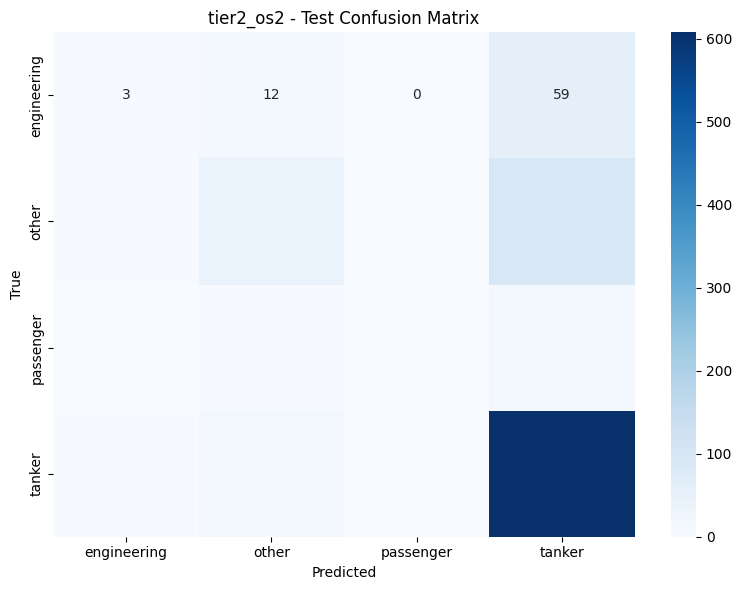


[tier2_fusar] Test Accuracy: 83.96% (403/480)
              precision    recall  f1-score   support

 engineering       0.42      0.22      0.29        23
       other       0.86      0.97      0.91       407
   passenger       0.00      0.00      0.00        11
      tanker       0.44      0.10      0.17        39

    accuracy                           0.84       480
   macro avg       0.43      0.32      0.34       480
weighted avg       0.79      0.84      0.80       480



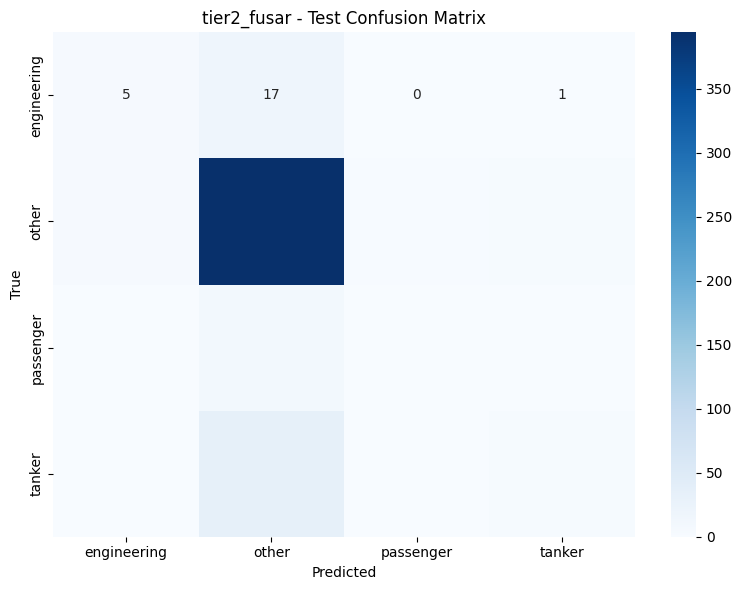


[tier2_joint] Test Accuracy: 77.21% (1328/1720)
              precision    recall  f1-score   support

 engineering       0.47      0.06      0.11       142
       other       0.82      0.73      0.77       602
   passenger       0.88      0.17      0.29        40
      tanker       0.75      0.93      0.83       936

    accuracy                           0.77      1720
   macro avg       0.73      0.48      0.50      1720
weighted avg       0.76      0.77      0.74      1720



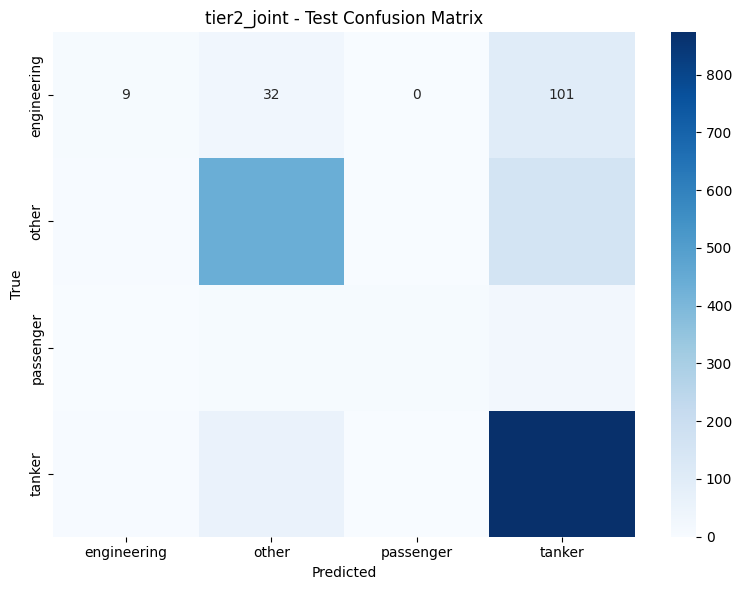

In [32]:
def evaluate_test(model, run_name, test_loader, class_names): # save_dir=MODELS_DIR
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = 100.0 * (all_preds == all_labels).sum() / len(all_labels)

    print(f"\n{'='*50}")
    print(f'[{run_name}] Test Accuracy: {acc:.2f}% ({(all_preds == all_labels).sum()}/{len(all_labels)})')
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{run_name} - Test Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    #cm_path = os.path.join(save_dir, f'{run_name}_confusion_matrix.png')
    #plt.savefig(cm_path, dpi=150)
    plt.show()

   #wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
   #           name=f'{run_name}_test', reinit=True)
   #wandb.log({'test_accuracy': acc,
   #           'test_confusion_matrix': wandb.plot.confusion_matrix(
   #               probs=None, y_true=all_labels.tolist(),
   #               preds=all_preds.tolist(), class_names=class_names)})
   #wandb.finish()
    return {'accuracy': acc, 'preds': all_preds, 'labels': all_labels}


# Evaluate all Tier 1 models
print('Running Tier 1 test evaluation...')
t1_results = {}
for name, d in tier1_domains.items():
    t1_results[name] = evaluate_test(d['trained_model'], f'tier1_{name}', d['test_loader'], TIER1_CLASS_NAMES)

# Evaluate all Tier 2 models
print('\nRunning Tier 2 test evaluation...')
t2_results = {}
for name, d in tier2_domains.items():
    t2_results[name] = evaluate_test(d['trained_model'], f'tier2_{name}', d['test_loader'], TIER2_CLASS_NAMES)


### Notes - Test Set Evaluation

Running evaluate_test on all 8 models, 4 Tier 1 and 4 Tier 2. Same function as the baseline, same per-class classification report and confusion matrix outputs.

For Tier 1 you want to see very high accuracy since binary problems are much easier. If Tier 1 is not performing well on the test set then the pipeline is broken at the first step and everything downstream will be wrong.

For Tier 2 compare the per-class F1 scores here against whatever the baseline single model got on those same non-cargo classes. That comparison is the actual evidence for whether the two-tier approach is worth it.


## Summary

In [34]:
print('\n' + '='*55)
print('  TIER 1 - BINARY CLASSIFIER TEST RESULTS')
print('='*55)
print(f'{"Dataset":<12} {"Best Val Acc":>14} {"Test Acc":>10}')
print('-'*55)
for name, d in tier1_domains.items():
    best_val = max(d['history']['val_acc'])
    test_acc = t1_results[name]['accuracy']
    print(f'{name:<12} {best_val:>13.2f}% {test_acc:>9.2f}%')

print('\n' + '='*55)
print('  TIER 2 - MULTI-CLASS (NON-CARGO) TEST RESULTS')
print('='*55)
print(f'{"Dataset":<12} {"Best Val Acc":>14} {"Test Acc":>10}')
print('-'*55)
for name, d in tier2_domains.items():
    best_val = max(d['history']['val_acc'])
    test_acc = t2_results[name]['accuracy']
    print(f'{name:<12} {best_val:>13.2f}% {test_acc:>9.2f}%')

#print('\nAll model checkpoints saved to:', MODELS_DIR)



  TIER 1 - BINARY CLASSIFIER TEST RESULTS
Dataset        Best Val Acc   Test Acc
-------------------------------------------------------
os1                  83.22%     81.61%
os2                  72.79%     71.90%
fusar                86.08%     84.13%
joint                77.99%     77.43%

  TIER 2 - MULTI-CLASS (NON-CARGO) TEST RESULTS
Dataset        Best Val Acc   Test Acc
-------------------------------------------------------
os1                  80.53%     78.74%
os2                  76.50%     75.43%
fusar                85.00%     83.96%
joint                77.33%     77.21%



### Notes - Summary

Two separate summary tables, one per tier. The Tier 1 numbers should be high if they are not, something is wrong with the binary setup. The Tier 2 numbers are the ones to bring to the team and compare against the baseline single-model results.

The joint model row in both tables is the most important one for the final pipeline since that is the one trained on all the data. The per-dataset rows show how much the sensor type affects performance which is relevant for the domain shift part of the project.
